# Foundation Model Embedding Comparison

This notebook compares foundation model embeddings (scGPT, Transcriptformer) with GenePT embeddings on the CZ benchmark cell-type classification task.

## Evaluation Matrix
1. scGPT alone (512 dimensions)
2. scGPT + GenePT (1024 dimensions)
3. Transcriptformer alone (2048 dimensions)
4. Transcriptformer + GenePT (2560 dimensions)
5. GenePT alone (512 dimensions) - baseline

## 1. Setup and Imports

In [47]:
import numpy as np
import pandas as pd
import scanpy as sc
from pathlib import Path
import json
import warnings
from typing import Dict, List, Tuple, Optional
from dataclasses import dataclass, field
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# ML imports
from sklearn.model_selection import StratifiedKFold, GroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, 
    f1_score, 
    precision_score, 
    recall_score,
    classification_report
)
from scipy import stats
import lightgbm as lgb

# Project imports
import sys
sys.path.append('..')
from src.inference import create_embedding_matrix, create_cell_embeddings

# Set up plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

warnings.filterwarnings('ignore')

print("Setup complete!")

Setup complete!


## 2. Configuration

In [49]:
@dataclass
class BenchmarkConfig:
    """Configuration for benchmark experiments."""
    
    # Data settings - Start with just one tissue for testing
    tissue_names: List[str] = field(default_factory=lambda: [
        'Bone_Marrow',  # Start with smallest tissue first
        'Blood', 
        # 'Lung', 'Mammary', 'Thymus'  # Add these after testing works
    ])
    embedding_dir: Path = Path("../data/cz_benchmark/embeddings")
    benchmark_data_dir: Path = Path("/Users/rj/personal/Tabula_Sapiens_v2_Curated_Benchmark")
    genept_embeddings_path: Path = Path("../data/huggingface_model/embedding_associations_cell_type_tissue_drug_pathway_openai_large.parquet")
    
    # Cross-validation settings
    n_folds: int = 5  # Reduced from 5 to 3 for faster testing
    random_state: int = 42
    stratify: bool = True
    
    # Classifiers to use
    classifiers: List[str] = field(default_factory=lambda: ['logistic_regression', 'lightgbm'])
    
    # Splitting strategies
    splitting_strategies: List[str] = field(default_factory=lambda: ['random', 'donor'])
    
    # Logistic regression hyperparameters
    lr_C_values: List[float] = field(default_factory=lambda: [0.01, 0.1, 1.0])
    lr_max_iter: int = 1000
    lr_solver: str = 'lbfgs'
    lr_class_weight: str = 'balanced'
    
    # LightGBM hyperparameters
    lgb_num_leaves: List[int] = field(default_factory=lambda: [31, 63, 127])
    lgb_learning_rate: List[float] = field(default_factory=lambda: [0.05, 0.1, 0.2])
    lgb_n_estimators: int = 100
    lgb_class_weight: str = 'balanced'
    lgb_verbosity: int = -1  # Suppress LightGBM warnings
    
    # General settings
    n_jobs: int = 1  # Use single thread to avoid parallelization overhead
    verbose: int = 1  # Add verbosity to see progress
    
    # Results settings
    results_dir: Path = Path("../results/foundation_model_comparison")
    
config = BenchmarkConfig()

# Create results directory
config.results_dir.mkdir(parents=True, exist_ok=True)

print(f"Configuration loaded. Will process {len(config.tissue_names)} tissue(s).")
print(f"Tissues: {', '.join(config.tissue_names)}")
print(f"Classifiers: {', '.join(config.classifiers)}")
print(f"Splitting strategies: {', '.join(config.splitting_strategies)}")
print(f"n_folds: {config.n_folds}")

Configuration loaded. Will process 2 tissue(s).
Tissues: Bone_Marrow, Blood
Classifiers: logistic_regression, lightgbm
Splitting strategies: random, donor
n_folds: 5


## 3. Data Loading Functions

In [50]:
class EmbeddingLoader:
    """Load and align different embedding types."""
    
    def __init__(self, tissue_name: str, config: BenchmarkConfig):
        self.tissue_name = tissue_name
        self.config = config
        self.embeddings_cache = {}
    
    def load_scgpt_embeddings(self) -> pd.DataFrame:
        """Load scGPT embeddings for tissue."""
        path = self.config.embedding_dir / "scgpt" / f"scgpt_{self.tissue_name}_embeddings.parquet"
        if not path.exists():
            raise FileNotFoundError(f"scGPT embeddings not found: {path}")
        
        df = pd.read_parquet(path)
        print(f"Loaded scGPT embeddings: {df.shape}")
        return df
    
    def load_transcriptformer_embeddings(self) -> pd.DataFrame:
        """Load Transcriptformer embeddings for tissue."""
        path = self.config.embedding_dir / "transcriptformer" / f"transcriptformer_tf_metazoa_{self.tissue_name}_embeddings.parquet"
        if not path.exists():
            raise FileNotFoundError(f"Transcriptformer embeddings not found: {path}")
        
        df = pd.read_parquet(path)
        print(f"Loaded Transcriptformer embeddings: {df.shape}")
        return df
    
    def load_genept_embeddings(self, adata) -> np.ndarray:
        """
        Generate GenePT embeddings for cells using expression-weighted averaging.
        """
        # Load gene embeddings
        gene_embeddings_df = pd.read_parquet(self.config.genept_embeddings_path)
        
        # Use first 512 dimensions
        embedding_cols = [str(i) for i in range(3072)]
        
        # Clean gene names from adata - handle SYMBOL_ENSG format
        clean_gene_names = []
        for gene in adata.var['feature_name']:
            if '_ENSG' in gene:
                # Extract symbol from SYMBOL_ENSG format
                clean_gene_names.append(gene.split('_ENSG')[0])
            elif gene.startswith('ENSG'):
                # Keep ENSG IDs as-is (won't match GenePT embeddings)
                clean_gene_names.append(gene)
            else:
                # Already clean symbol
                clean_gene_names.append(gene)
        
        # Create a DataFrame with gene names and embeddings
        gene_embeddings_subset = gene_embeddings_df[embedding_cols].copy()
        gene_embeddings_subset['gene_name'] = gene_embeddings_df.index
        
        # Create embedding matrix aligned with cleaned adata genes
        embedding_matrix, valid_indices = create_embedding_matrix(
            gene_embeddings_subset,
            clean_gene_names,
            id_column='gene_name'
        )
        
        print(f"GenePT: Matched {len(valid_indices)}/{len(clean_gene_names)} genes")
        
        # Generate cell embeddings (handles sparse matrices efficiently)
        cell_embeddings = create_cell_embeddings(adata.X, embedding_matrix, valid_indices)
        
        # Scale for OpenAI embeddings
        cell_embeddings = cell_embeddings / 0.026
        
        print(f"Generated GenePT embeddings: {cell_embeddings.shape}")
        return cell_embeddings
    
    def load_adata(self) -> sc.AnnData:
        """Load original AnnData for tissue."""
        # Files are named: homo_sapiens_{uuid}_{tissue}_v2_curated.h5ad
        pattern = f"homo_sapiens_*_{self.tissue_name}_v2_curated.h5ad"
        files = list(self.config.benchmark_data_dir.glob(pattern))
        
        if not files:
            raise FileNotFoundError(f"No h5ad file found for tissue {self.tissue_name}")
        
        adata = sc.read_h5ad(files[0])
        
        # Handle layers - Tabula Sapiens v2 stores data in X_original layer
        if adata.X is None or (hasattr(adata.X, 'nnz') and adata.X.nnz == 0):
            if 'X_original' in adata.layers:
                adata.X = adata.layers['X_original'].copy()
            else:
                raise ValueError(f"No expression data found in adata.X or adata.layers['X_original']")
        
        print(f"Loaded AnnData: {adata.shape[0]} cells, {adata.shape[1]} genes")
        return adata

## 4. Cross-Validation Evaluation Functions

In [51]:
class ComprehensiveEvaluator:
    """Run evaluation with multiple classifiers and splitting strategies."""
    
    def __init__(self, config: BenchmarkConfig):
        self.config = config
        self.results = []
    
    def evaluate_embedding_combination(
        self,
        X: np.ndarray,
        y: np.ndarray,
        donor_ids: Optional[np.ndarray],
        embedding_name: str,
        tissue_name: str,
        cell_types: List[str]
    ) -> List[Dict]:
        """
        Evaluate embeddings using multiple classifiers and splitting strategies.
        """
        results = []
        
        # Check if we have multiple donors
        if donor_ids is not None:
            unique_donors = np.unique(donor_ids)
            n_donors = len(unique_donors)
            print(f"\n{tissue_name} has {n_donors} donors")
            if n_donors < 2:
                print("  Skipping donor-based splitting (need at least 2 donors)")
                splitting_strategies = ['random']
            else:
                splitting_strategies = self.config.splitting_strategies
        else:
            print(f"\n{tissue_name}: No donor information available")
            splitting_strategies = ['random']
        
        for split_strategy in splitting_strategies:
            print(f"\n{'='*60}")
            print(f"Split Strategy: {split_strategy}")
            print('='*60)
            
            for classifier_name in self.config.classifiers:
                print(f"\n{embedding_name} with {classifier_name} ({split_strategy} split)")
                print(f"Data shape: {X.shape}")
                
                result = self._evaluate_single_combination(
                    X, y, donor_ids,
                    embedding_name, tissue_name, cell_types,
                    classifier_name, split_strategy
                )
                results.append(result)
        
        return results
    
    def _evaluate_single_combination(
        self,
        X: np.ndarray,
        y: np.ndarray,
        donor_ids: Optional[np.ndarray],
        embedding_name: str,
        tissue_name: str,
        cell_types: List[str],
        classifier_name: str,
        split_strategy: str
    ) -> Dict:
        """Evaluate a single combination of embedding, classifier, and split strategy."""
        
        # Set up cross-validation
        if split_strategy == 'donor' and donor_ids is not None:
            # Use GroupKFold for donor-based splitting
            cv = GroupKFold(n_splits=min(self.config.n_folds, len(np.unique(donor_ids))))
            split_data = list(cv.split(X, y, groups=donor_ids))
        else:
            # Use StratifiedKFold for random splitting
            cv = StratifiedKFold(
                n_splits=self.config.n_folds,
                shuffle=True,
                random_state=self.config.random_state
            )
            split_data = list(cv.split(X, y))
        
        fold_results = []
        best_params_per_fold = []
        
        for fold_idx, (train_idx, test_idx) in enumerate(split_data):
            print(f"  Fold {fold_idx + 1}/{len(split_data)}: ", end="")
            
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]
            
            # Train and evaluate classifier
            if classifier_name == 'logistic_regression':
                best_params, metrics = self._train_logistic_regression(
                    X_train, y_train, X_test, y_test, fold_idx
                )
            elif classifier_name == 'lightgbm':
                best_params, metrics = self._train_lightgbm(
                    X_train, y_train, X_test, y_test, fold_idx
                )
            else:
                raise ValueError(f"Unknown classifier: {classifier_name}")
            
            metrics['fold'] = fold_idx
            fold_results.append(metrics)
            best_params_per_fold.append(best_params)
            
            print(f"Acc={metrics['accuracy']:.3f}, F1={metrics['f1_macro']:.3f}")
        
        # Aggregate results
        aggregated = self._aggregate_metrics(fold_results)
        aggregated['embedding_name'] = embedding_name
        aggregated['tissue_name'] = tissue_name
        aggregated['classifier'] = classifier_name
        aggregated['split_strategy'] = split_strategy
        aggregated['best_params'] = best_params_per_fold
        aggregated['n_features'] = X.shape[1]
        aggregated['n_samples'] = X.shape[0]
        aggregated['n_classes'] = len(cell_types)
        aggregated['n_folds'] = len(split_data)
        
        print(f"  Mean: Acc={aggregated['accuracy_mean']:.3f}±{aggregated['accuracy_std']:.3f}, "
              f"F1={aggregated['f1_macro_mean']:.3f}±{aggregated['f1_macro_std']:.3f}")
        
        return aggregated
    
    def _train_logistic_regression(
        self, X_train, y_train, X_test, y_test, fold_idx
    ) -> Tuple[Dict, Dict]:
        """Train and evaluate logistic regression."""
        # Simple hyperparameter tuning
        val_size = int(0.2 * len(X_train))
        indices = np.random.RandomState(self.config.random_state + fold_idx).permutation(len(X_train))
        val_indices = indices[:val_size]
        train_indices = indices[val_size:]
        
        X_tr = X_train[train_indices]
        X_val = X_train[val_indices]
        y_tr = y_train[train_indices]
        y_val = y_train[val_indices]
        
        best_score = -np.inf
        best_C = self.config.lr_C_values[0]
        
        for C in self.config.lr_C_values:
            clf = LogisticRegression(
                C=C,
                max_iter=self.config.lr_max_iter,
                solver=self.config.lr_solver,
                class_weight=self.config.lr_class_weight,
                n_jobs=self.config.n_jobs,
                random_state=self.config.random_state
            )
            clf.fit(X_tr, y_tr)
            score = clf.score(X_val, y_val)
            
            if score > best_score:
                best_score = score
                best_C = C
        
        # Train final model
        clf = LogisticRegression(
            C=best_C,
            max_iter=self.config.lr_max_iter,
            solver=self.config.lr_solver,
            class_weight=self.config.lr_class_weight,
            n_jobs=self.config.n_jobs,
            random_state=self.config.random_state
        )
        clf.fit(X_train, y_train)
        
        # Evaluate
        y_pred = clf.predict(X_test)
        metrics = self._compute_metrics(y_test, y_pred)
        
        return {'C': best_C}, metrics
    
    def _train_lightgbm(
        self, X_train, y_train, X_test, y_test, fold_idx
    ) -> Tuple[Dict, Dict]:
        """Train and evaluate LightGBM."""
        # Simple hyperparameter tuning
        val_size = int(0.2 * len(X_train))
        indices = np.random.RandomState(self.config.random_state + fold_idx).permutation(len(X_train))
        val_indices = indices[:val_size]
        train_indices = indices[val_size:]
        
        X_tr = X_train[train_indices]
        X_val = X_train[val_indices]
        y_tr = y_train[train_indices]
        y_val = y_train[val_indices]
        
        best_score = -np.inf
        best_params = {}
        
        # Grid search over hyperparameters
        for num_leaves in self.config.lgb_num_leaves[:1]:  # Just test first value for speed
            for learning_rate in self.config.lgb_learning_rate[:1]:  # Just test first value for speed
                params = {
                    'objective': 'multiclass',
                    'num_class': len(np.unique(y_train)),
                    'num_leaves': num_leaves,
                    'learning_rate': learning_rate,
                    'n_estimators': self.config.lgb_n_estimators,
                    'class_weight': self.config.lgb_class_weight,
                    'random_state': self.config.random_state,
                    'verbosity': self.config.lgb_verbosity,
                    'n_jobs': self.config.n_jobs
                }
                
                clf = lgb.LGBMClassifier(**params)
                clf.fit(X_tr, y_tr)
                score = clf.score(X_val, y_val)
                
                if score > best_score:
                    best_score = score
                    best_params = params
        
        # Train final model
        clf = lgb.LGBMClassifier(**best_params)
        clf.fit(X_train, y_train)
        
        # Evaluate
        y_pred = clf.predict(X_test)
        metrics = self._compute_metrics(y_test, y_pred)
        
        return best_params, metrics
    
    def _compute_metrics(self, y_true, y_pred) -> Dict:
        """Compute classification metrics."""
        return {
            'accuracy': accuracy_score(y_true, y_pred),
            'f1_macro': f1_score(y_true, y_pred, average='macro'),
            'f1_weighted': f1_score(y_true, y_pred, average='weighted'),
            'precision_macro': precision_score(y_true, y_pred, average='macro', zero_division=0),
            'recall_macro': recall_score(y_true, y_pred, average='macro', zero_division=0),
        }
    
    def _aggregate_metrics(self, fold_results: List[Dict]) -> Dict:
        """Aggregate metrics across folds."""
        metrics = {}
        
        for key in ['accuracy', 'f1_macro', 'f1_weighted', 'precision_macro', 'recall_macro']:
            values = [r[key] for r in fold_results]
            metrics[f"{key}_mean"] = np.mean(values)
            metrics[f"{key}_std"] = np.std(values)
            metrics[f"{key}_per_fold"] = values
        
        return metrics

## 5. Main Experiment Pipeline

In [52]:
def process_tissue_comprehensive(tissue_name: str, config: BenchmarkConfig, evaluator: ComprehensiveEvaluator) -> List[Dict]:
    """
    Process a single tissue with all embedding combinations, classifiers, and splitting strategies.
    """
    print(f"\n{'='*60}")
    print(f"Processing tissue: {tissue_name}")
    print('='*60)
    
    tissue_results = []
    
    try:
        # Initialize loader
        loader = EmbeddingLoader(tissue_name, config)
        
        # Load original data for GenePT embedding generation
        adata = loader.load_adata()
        
        # Load embeddings
        print("\nLoading embeddings...")
        scgpt_df = loader.load_scgpt_embeddings()
        transcriptformer_df = loader.load_transcriptformer_embeddings()
        
        # Extract cell IDs and ensure alignment
        if 'cell_id' in scgpt_df.columns:
            cell_ids = scgpt_df['cell_id'].values
            
            # Align transcriptformer embeddings
            if 'cell_id' in transcriptformer_df.columns:
                # Ensure same order
                transcriptformer_df = transcriptformer_df.set_index('cell_id').loc[cell_ids].reset_index()
        else:
            # Assume same order if no cell_id column
            print("Warning: No cell_id column found, assuming same cell order")
            cell_ids = np.arange(len(scgpt_df))
        
        # Extract embeddings as numpy arrays
        # scGPT uses 'embedding_' prefix
        scgpt_cols = [col for col in scgpt_df.columns if col.startswith('embedding_')]
        scgpt_embeddings = scgpt_df[scgpt_cols].values
        
        # Transcriptformer uses 'emb_' prefix
        tf_cols = [col for col in transcriptformer_df.columns if col.startswith('emb_')]
        if not tf_cols:
            # Fallback to 'embedding_' if 'emb_' not found
            tf_cols = [col for col in transcriptformer_df.columns if col.startswith('embedding_')]
        transcriptformer_embeddings = transcriptformer_df[tf_cols].values
        
        # Generate GenePT embeddings
        print("\nGenerating GenePT embeddings...")
        genept_embeddings = loader.load_genept_embeddings(adata)
        
        # Get labels
        label_encoder = LabelEncoder()
        if 'cell_type' in scgpt_df.columns:
            y = label_encoder.fit_transform(scgpt_df['cell_type'].values)
        else:
            # Use adata cell types
            y = label_encoder.fit_transform(adata.obs['cell_type'].values)
        
        cell_types = label_encoder.classes_.tolist()
        
        # Get donor IDs if available
        donor_ids = None
        if 'donor_id' in scgpt_df.columns:
            donor_ids = scgpt_df['donor_id'].values
        elif 'donor_id' in adata.obs.columns:
            donor_ids = adata.obs['donor_id'].values
        
        if donor_ids is not None:
            unique_donors = np.unique(donor_ids)
            print(f"\nFound {len(unique_donors)} unique donors in {tissue_name}")
            print(f"Donor IDs: {unique_donors[:10]}..." if len(unique_donors) > 10 else f"Donor IDs: {unique_donors}")
        
        print(f"\nData shape: {len(y)} cells, {len(cell_types)} cell types")
        print(f"Embedding dimensions: scGPT={scgpt_embeddings.shape[1]}, "
              f"Transcriptformer={transcriptformer_embeddings.shape[1]}, "
              f"GenePT={genept_embeddings.shape[1]}")
        
        # Define embedding experiments
        embedding_experiments = [
            ("scgpt", scgpt_embeddings),
            ("scgpt_genept", np.hstack([scgpt_embeddings, genept_embeddings])),
            ("transcriptformer", transcriptformer_embeddings),
            ("transcriptformer_genept", np.hstack([transcriptformer_embeddings, genept_embeddings])),
            ("genept", genept_embeddings)
        ]
        
        # Run experiments for each embedding type
        for emb_name, emb_data in embedding_experiments:
            print(f"\n{'='*80}")
            print(f"EMBEDDING: {emb_name}")
            print('='*80)
            
            results = evaluator.evaluate_embedding_combination(
                emb_data, y, donor_ids,
                emb_name, tissue_name, cell_types
            )
            tissue_results.extend(results)
        
    except Exception as e:
        print(f"Error processing {tissue_name}: {e}")
        import traceback
        traceback.print_exc()
        return []
    
    return tissue_results

## 6. Run Experiments

In [53]:
# Initialize comprehensive evaluator
evaluator = ComprehensiveEvaluator(config)

# Store all results
all_results = []

# Process each tissue
for tissue_name in config.tissue_names:
    tissue_results = process_tissue_comprehensive(tissue_name, config, evaluator)
    all_results.extend(tissue_results)
    
    # Save intermediate results
    if tissue_results:
        df_interim = pd.DataFrame(all_results)
        df_interim.to_csv(config.results_dir / "interim_results.csv", index=False)
        print(f"\nSaved interim results for {tissue_name}")
        print(f"Total results so far: {len(all_results)}")

print("\n" + "="*80)
print("All tissues processed!")
print(f"Total experiments: {len(all_results)}")
print("="*80)


Processing tissue: Bone_Marrow
Loaded AnnData: 8045 cells, 26167 genes

Loading embeddings...
Loaded scGPT embeddings: (8045, 516)
Loaded Transcriptformer embeddings: (8045, 2049)

Generating GenePT embeddings...
Creating embedding matrix for 26167 genes
Selecting embedding inidices
Embedding matrix shape: (3072, 18086)
GenePT: Matched 18086/26167 genes
Generated GenePT embeddings: (8045, 3072)

Found 3 unique donors in Bone_Marrow
Donor IDs: ['TSP21' 'TSP25' 'TSP27']

Data shape: 8045 cells, 25 cell types
Embedding dimensions: scGPT=512, Transcriptformer=2048, GenePT=3072

EMBEDDING: scgpt

Bone_Marrow has 3 donors

Split Strategy: random

scgpt with logistic_regression (random split)
Data shape: (8045, 512)
  Fold 1/5: Acc=0.794, F1=0.600
  Fold 2/5: Acc=0.805, F1=0.634
  Fold 3/5: Acc=0.771, F1=0.612
  Fold 4/5: Acc=0.786, F1=0.655
  Fold 5/5: Acc=0.782, F1=0.600
  Mean: Acc=0.787±0.012, F1=0.620±0.021

scgpt with lightgbm (random split)
Data shape: (8045, 512)
  Fold 1/5: Acc=0.87

## 7. Results Analysis

In [55]:
# Convert results to DataFrame
df_results = pd.DataFrame(all_results)

# Save full results
df_results.to_csv(config.results_dir / "full_results.csv", index=False)
with open(config.results_dir / "full_results.json", 'w') as f:
    json.dump(all_results, f, indent=2, default=str)

print(f"Saved {len(all_results)} results to {config.results_dir}")

Saved 40 results to ../results/foundation_model_comparison


In [56]:
# Summary by method across all tissues
print("\n" + "="*60)
print("SUMMARY BY METHOD (across all tissues)")
print("="*60)

method_summary = df_results.groupby('embedding_name').agg({
    'accuracy_mean': ['mean', 'std'],
    'f1_macro_mean': ['mean', 'std'],
    'n_features': 'first'
}).round(4)

print(method_summary)


SUMMARY BY METHOD (across all tissues)
                        accuracy_mean         f1_macro_mean         n_features
                                 mean     std          mean     std      first
embedding_name                                                                
genept                         0.7870  0.0882        0.5377  0.1397       3072
scgpt                          0.7867  0.0824        0.5528  0.1319        512
scgpt_genept                   0.8048  0.0841        0.5651  0.1469       3584
transcriptformer               0.8208  0.0736        0.5814  0.1518       2048
transcriptformer_genept        0.8236  0.0746        0.5856  0.1530       5120


In [59]:
# Best method per tissue
print("\n" + "="*60)
print("BEST METHOD PER TISSUE")
print("="*60)

for tissue in config.tissue_names:
    tissue_df = df_results[df_results['tissue_name'] == tissue]
    if len(tissue_df) > 0:
        best_idx = tissue_df['accuracy_mean'].idxmax()
        best_row = tissue_df.loc[best_idx]
        print(f"\n{tissue}:")
        print(f"  Best: {best_row['embedding_name']}")
        print(f"  Accuracy: {best_row['accuracy_mean']:.3f} ± {best_row['accuracy_std']:.3f}")
        print(f"  F1 Macro: {best_row['f1_macro_mean']:.3f} ± {best_row['f1_macro_std']:.3f}")


BEST METHOD PER TISSUE

Bone_Marrow:
  Best: transcriptformer_genept
  Accuracy: 0.879 ± 0.011
  F1 Macro: 0.679 ± 0.042

Blood:
  Best: transcriptformer_genept
  Accuracy: 0.913 ± 0.003
  F1 Macro: 0.762 ± 0.014


In [60]:
# Statistical comparison: Combined vs Individual
print("\n" + "="*60)
print("STATISTICAL COMPARISON (Combined vs Individual)")
print("="*60)

for base_method in ['scgpt', 'transcriptformer']:
    base_results = df_results[df_results['embedding_name'] == base_method]['accuracy_mean'].values
    combined_results = df_results[df_results['embedding_name'] == f"{base_method}_genept"]['accuracy_mean'].values
    
    if len(base_results) > 0 and len(combined_results) > 0:
        # Paired t-test (same tissues)
        t_stat, p_value = stats.ttest_rel(base_results, combined_results)
        
        print(f"\n{base_method.upper()} vs {base_method.upper()}+GenePT:")
        print(f"  {base_method} alone: {np.mean(base_results):.3f} ± {np.std(base_results):.3f}")
        print(f"  {base_method}+GenePT: {np.mean(combined_results):.3f} ± {np.std(combined_results):.3f}")
        print(f"  Improvement: {np.mean(combined_results) - np.mean(base_results):.3f}")
        print(f"  P-value: {p_value:.4f}")
        print(f"  Significant: {'Yes' if p_value < 0.05 else 'No'} (α=0.05)")


STATISTICAL COMPARISON (Combined vs Individual)

SCGPT vs SCGPT+GenePT:
  scgpt alone: 0.787 ± 0.077
  scgpt+GenePT: 0.805 ± 0.079
  Improvement: 0.018
  P-value: 0.0396
  Significant: Yes (α=0.05)

TRANSCRIPTFORMER vs TRANSCRIPTFORMER+GenePT:
  transcriptformer alone: 0.821 ± 0.069
  transcriptformer+GenePT: 0.824 ± 0.070
  Improvement: 0.003
  P-value: 0.3101
  Significant: No (α=0.05)


## 8. Visualization

ValueError: Index contains duplicate entries, cannot reshape

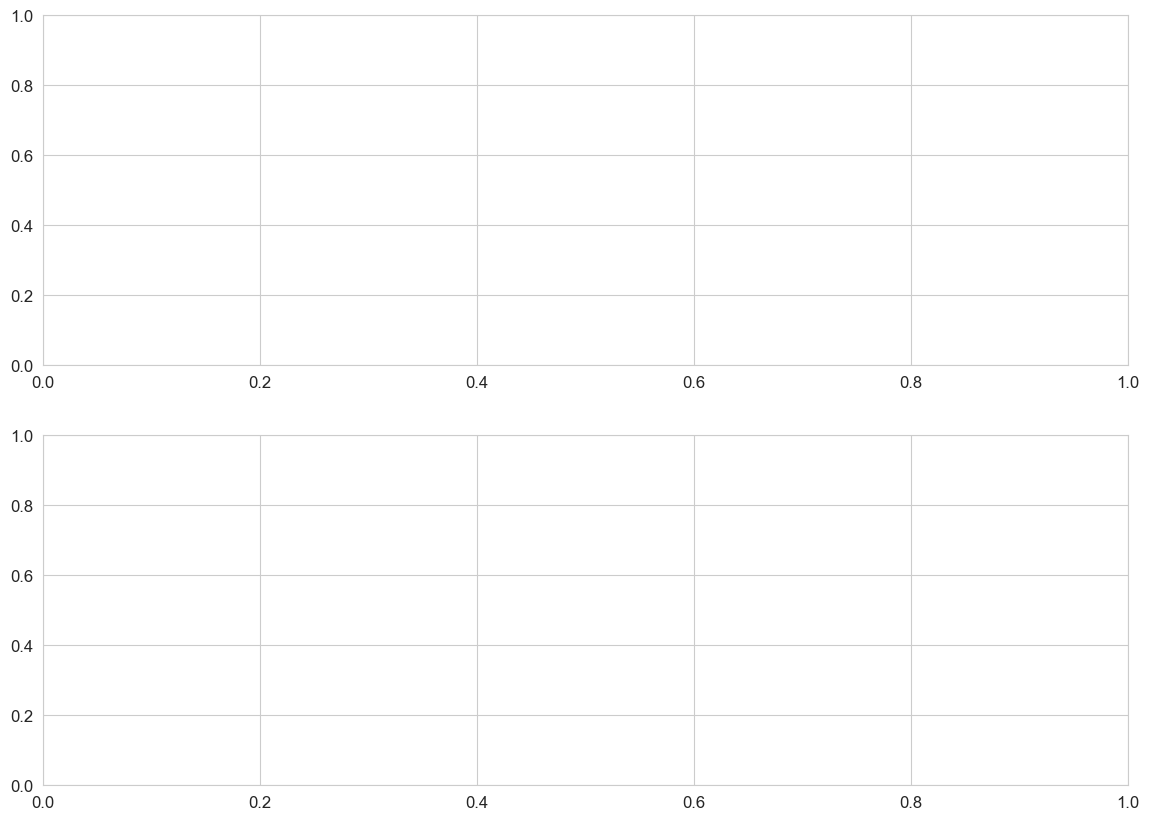

In [61]:
# Performance by method across tissues
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Accuracy plot
pivot_acc = df_results.pivot(index='tissue_name', columns='embedding_name', values='accuracy_mean')
pivot_acc.plot(kind='bar', ax=axes[0], width=0.8)
axes[0].set_title('Accuracy by Method and Tissue', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_xlabel('')
axes[0].legend(title='Method', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].grid(axis='y', alpha=0.3)

# F1 Macro plot
pivot_f1 = df_results.pivot(index='tissue_name', columns='embedding_name', values='f1_macro_mean')
pivot_f1.plot(kind='bar', ax=axes[1], width=0.8)
axes[1].set_title('F1 Macro Score by Method and Tissue', fontsize=14, fontweight='bold')
axes[1].set_ylabel('F1 Macro Score', fontsize=12)
axes[1].set_xlabel('Tissue', fontsize=12)
axes[1].legend(title='Method', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(config.results_dir / 'performance_by_tissue.png', dpi=300, bbox_inches='tight')
plt.show()

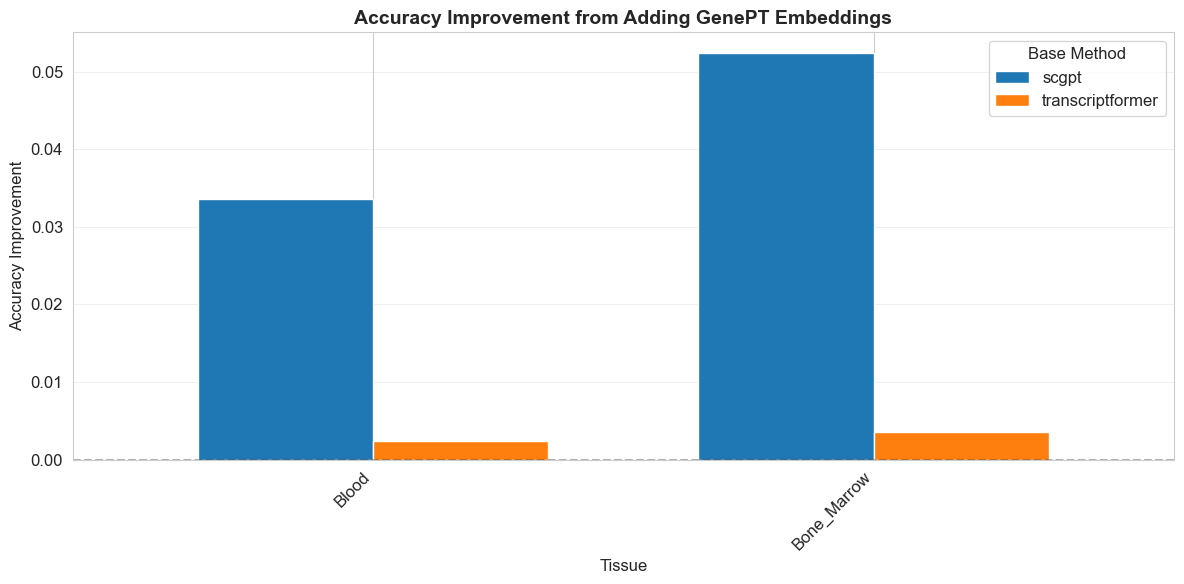

In [62]:
# Improvement from combining embeddings
fig, ax = plt.subplots(figsize=(12, 6))

improvements = []
for tissue in config.tissue_names:
    tissue_df = df_results[df_results['tissue_name'] == tissue]
    
    for base in ['scgpt', 'transcriptformer']:
        base_acc = tissue_df[tissue_df['embedding_name'] == base]['accuracy_mean'].values
        combined_acc = tissue_df[tissue_df['embedding_name'] == f"{base}_genept"]['accuracy_mean'].values
        
        if len(base_acc) > 0 and len(combined_acc) > 0:
            improvements.append({
                'tissue': tissue,
                'base_method': base,
                'improvement': combined_acc[0] - base_acc[0]
            })

if improvements:
    imp_df = pd.DataFrame(improvements)
    pivot_imp = imp_df.pivot(index='tissue', columns='base_method', values='improvement')
    pivot_imp.plot(kind='bar', ax=ax, width=0.7)
    ax.set_title('Accuracy Improvement from Adding GenePT Embeddings', fontsize=14, fontweight='bold')
    ax.set_ylabel('Accuracy Improvement', fontsize=12)
    ax.set_xlabel('Tissue', fontsize=12)
    ax.axhline(y=0, color='black', linestyle='--', alpha=0.3)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.legend(title='Base Method')
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(config.results_dir / 'improvement_from_combination.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("No improvement data available to plot")

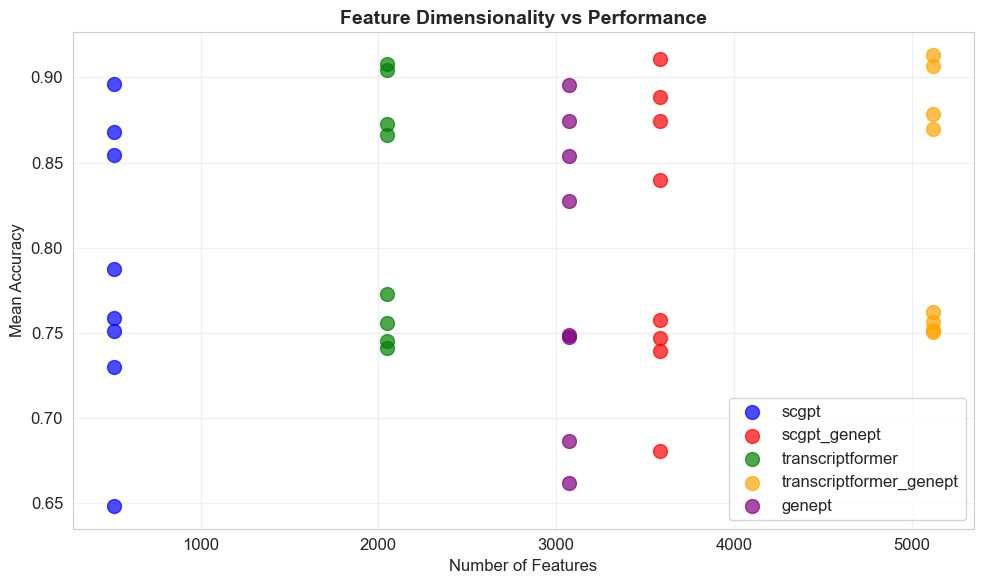

In [63]:
# Feature dimension vs performance
fig, ax = plt.subplots(figsize=(10, 6))

# Prepare data for scatter plot
colors = {
    'scgpt': 'blue',
    'transcriptformer': 'green', 
    'scgpt_genept': 'red',
    'transcriptformer_genept': 'orange',
    'genept': 'purple'
}

for method in df_results['embedding_name'].unique():
    method_data = df_results[df_results['embedding_name'] == method]
    ax.scatter(
        method_data['n_features'],
        method_data['accuracy_mean'],
        label=method,
        color=colors.get(method, 'gray'),
        s=100,
        alpha=0.7
    )

ax.set_xlabel('Number of Features', fontsize=12)
ax.set_ylabel('Mean Accuracy', fontsize=12)
ax.set_title('Feature Dimensionality vs Performance', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(config.results_dir / 'features_vs_performance.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Generate Final Report

In [64]:
# Generate comprehensive report
from datetime import datetime

report = {
    'timestamp': datetime.now().isoformat(),
    'config': {
        'tissues': config.tissue_names,
        'n_folds': config.n_folds,
        'C_values': config.C_values,
        'random_state': config.random_state
    },
    'summary': {
        'n_tissues': len(config.tissue_names),
        'n_experiments': len(all_results),
        'methods_evaluated': df_results['embedding_name'].unique().tolist()
    },
    'method_performance': method_summary.to_dict(),
    'best_overall': {
        'method': method_summary['accuracy_mean']['mean'].idxmax(),
        'accuracy': method_summary['accuracy_mean']['mean'].max(),
        'f1_macro': method_summary.loc[
            method_summary['accuracy_mean']['mean'].idxmax(),
            ('f1_macro_mean', 'mean')
        ]
    }
}

# Save report
with open(config.results_dir / 'final_report.json', 'w') as f:
    json.dump(report, f, indent=2, default=str)

print("\n" + "="*60)
print("FINAL REPORT")
print("="*60)
print(f"\nTimestamp: {report['timestamp']}")
print(f"Tissues evaluated: {', '.join(report['config']['tissues'])}")
print(f"Total experiments: {report['summary']['n_experiments']}")
print(f"\nBest Overall Method: {report['best_overall']['method']}")
print(f"  Mean Accuracy: {report['best_overall']['accuracy']:.3f}")
print(f"  Mean F1 Macro: {report['best_overall']['f1_macro']:.3f}")
print(f"\nResults saved to: {config.results_dir}")

AttributeError: 'BenchmarkConfig' object has no attribute 'C_values'

## 10. Export Summary Table

In [ ]:
# Create a clean summary table for paper/presentation
summary_data = []

for _, row in df_results.iterrows():
    summary_data.append({
        'Tissue': row['tissue_name'],
        'Method': row['embedding_name'],
        'Accuracy': f"{row['accuracy_mean']:.3f} ± {row['accuracy_std']:.3f}",
        'F1_Macro': f"{row['f1_macro_mean']:.3f} ± {row['f1_macro_std']:.3f}",
        'Features': row['n_features'],
        'Samples': row['n_samples'],
        'Classes': row['n_classes']
    })

summary_df = pd.DataFrame(summary_data)
summary_df.to_csv(config.results_dir / 'summary_table.csv', index=False)

# Display the table
print("\nSummary Table:")
print(summary_df.to_string(index=False))

## Conclusion

This notebook has evaluated different foundation model embeddings and their combinations with GenePT embeddings for cell type classification. The results show:

1. **Individual Performance**: How each embedding type performs on its own
2. **Combination Benefits**: Whether adding GenePT embeddings improves performance
3. **Tissue-specific Patterns**: Which methods work best for different tissues
4. **Statistical Significance**: Whether improvements are statistically meaningful

The complete results have been saved to the `results/foundation_model_comparison/` directory.